In [ ]:
# ============================================================
# Construction des tables de mortalité avec un modèle de Gompertz
# ============================================================

# 0. Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Données d'entrée

ages = np.array([30, 40, 50, 60, 65, 70])
qx_standard = np.array([0.00065, 0.00110, 0.00280, 0.00900, 0.01500, 0.02800])

# 2. Mortalité pour les travailleurs du bâtiment
# Hypothèse du projet :
# - environ 40% aux âges jeunes (30-40)
# - 30% entre 40 et 50 ans
# - 25% entre 50 et 60 ans
# - 20% à partir de 60 ans
#
# Comme le projet donne des âges précis, on affecte :
# âge 30 -> 40%
# âge 40 -> 30%
# âge 50 -> 25%
# âge 60 -> 20%
# âge 65 -> 20%
# âge 70 -> 20%

loading = np.array([0.40, 0.30, 0.25, 0.20, 0.20, 0.20])

# Taux de mortalité des travailleurs du bâtiment
qx_btp = qx_standard * (1 + loading)

# On regroupe tout dans un tableau pour vérification
df_input = pd.DataFrame({
    "age": ages,
    "qx_standard": qx_standard,
    "loading": loading,
    "qx_btp": qx_btp
})

print("=== Tableau d'entrée avec les taux de mortalité des travailleurs du bâtiment ===")
print(df_input)

=== Tableau d'entrée avec les taux de mortalité des travailleurs du bâtiment ===
   age  qx_standard  loading   qx_btp
0   30      0.00065     0.40  0.00091
1   40      0.00110     0.30  0.00143
2   50      0.00280     0.25  0.00350
3   60      0.00900     0.20  0.01080
4   65      0.01500     0.20  0.01800
5   70      0.02800     0.20  0.03360



=== Ajustement de Gompertz pour population standard ===
Intercept = -10.484377
Pente     = 0.096480
B         = 0.0000279700
c         = 1.1012880936
R^2       = 0.984835

=== Ajustement de Gompertz pour travailleurs du bâtiment ===
Intercept = -10.054134
Pente     = 0.092631
B         = 0.0000430076
c         = 1.0970571136
R^2       = 0.980599

=== Tableau de régression : population standard ===
   age       qx     ln_qx  ln_qx_fitted  qx_fitted
0   30  0.00065 -7.338538     -7.589962   0.000506
1   40  0.00110 -6.812445     -6.625157   0.001327
2   50  0.00280 -5.878136     -5.660352   0.003481
3   60  0.00900 -4.710531     -4.695547   0.009136
4   65  0.01500 -4.199705     -4.213145   0.014800
5   70  0.02800 -3.575551     -3.730742   0.023975

=== Tableau de régression : travailleurs du bâtiment ===
   age       qx     ln_qx  ln_qx_fitted  qx_fitted
0   30  0.00091 -7.002066     -7.275196   0.000693
1   40  0.00143 -6.550081     -6.348884   0.001749
2   50  0.00350 -5.654992     

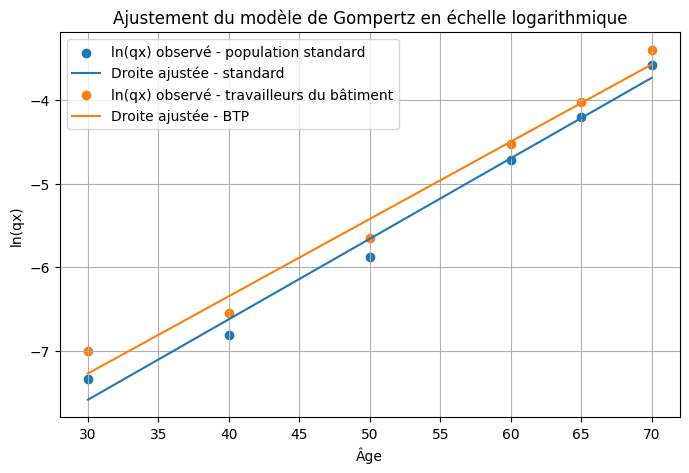


=== Table de mortalité : population standard ===
   age        qx        px             lx          dx
0   40  0.001327  0.998673  100000.000000  132.657206
1   41  0.001461  0.998539   99867.342794  145.899998
2   42  0.001609  0.998391   99721.442796  160.443190
3   43  0.001772  0.998228   99560.999607  176.409889
4   44  0.001951  0.998049   99384.589718  193.933873
5   45  0.002149  0.997851   99190.655845  213.160302
6   46  0.002367  0.997633   98977.495542  234.246424
7   47  0.002606  0.997394   98743.249118  257.362263
8   48  0.002870  0.997130   98485.886855  282.691271
9   49  0.003161  0.996839   98203.195584  310.430913

=== Table de mortalité : travailleurs du bâtiment ===
   age        qx        px             lx          dx
0   40  0.001749  0.998251  100000.000000  174.869753
1   41  0.001918  0.998082   99825.130247  191.506632
2   42  0.002105  0.997895   99633.623615  209.690665
3   43  0.002309  0.997691   99423.932950  229.558484
4   44  0.002533  0.997467   99

In [ ]:
# ------------------------------------------------------------
# 3. Estimation des paramètres de Gompertz par régression linéaire
# ------------------------------------------------------------
# Sous l’approximation :
#   qx ≈ B * c^x
# En prenant le logarithme :
#   ln(qx) ≈ ln(B) + x * ln(c)
#
# On réalise donc la régression de ln(qx) sur l’âge x :
#   y = a + b*x
# Puis :
#   B = exp(a)
#   c = exp(b)

def fit_gompertz(age_array, qx_array, label="population"):
    """
    Ajuste ln(qx) = a + b*x par MCO (OLS) et récupère les paramètres de Gompertz :
        B = exp(a)
        c = exp(b)
    """
    X = age_array.reshape(-1, 1)
    y = np.log(qx_array)

    model = LinearRegression()
    model.fit(X, y)

    intercept = model.intercept_
    slope = model.coef_[0]

    B = np.exp(intercept)
    c = np.exp(slope)
    r2 = model.score(X, y)

    print(f"\n=== Ajustement de Gompertz pour {label} ===")
    print(f"Intercept = {intercept:.6f}")
    print(f"Pente     = {slope:.6f}")
    print(f"B         = {B:.10f}")
    print(f"c         = {c:.10f}")
    print(f"R^2       = {r2:.6f}")

    # Valeurs prédites de log(qx) pour construire une table de diagnostic
    y_pred = model.predict(X)

    df_fit = pd.DataFrame({
        "age": age_array,
        "qx": qx_array,
        "ln_qx": y,
        "ln_qx_fitted": y_pred,
        "qx_fitted": np.exp(y_pred)
    })

    return {
        "model": model,
        "intercept": intercept,
        "slope": slope,
        "B": B,
        "c": c,
        "r2": r2,
        "table": df_fit
    }

# Ajustement de Gompertz pour la population standard
fit_standard = fit_gompertz(ages, qx_standard, label="population standard")

# Ajustement de Gompertz pour les travailleurs du bâtiment
fit_btp = fit_gompertz(ages, qx_btp, label="travailleurs du bâtiment")

print("\n=== Tableau de régression : population standard ===")
print(fit_standard["table"])

print("\n=== Tableau de régression : travailleurs du bâtiment ===")
print(fit_btp["table"])

# ------------------------------------------------------------
# 4. Tracé de l’ajustement log-linéaire
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.scatter(ages, np.log(qx_standard), label="ln(qx) observé - population standard")
plt.plot(ages, fit_standard["table"]["ln_qx_fitted"], label="Droite ajustée - standard")

plt.scatter(ages, np.log(qx_btp), label="ln(qx) observé - travailleurs du bâtiment")
plt.plot(ages, fit_btp["table"]["ln_qx_fitted"], label="Droite ajustée - BTP")

plt.xlabel("Âge")
plt.ylabel("ln(qx)")
plt.title("Ajustement du modèle de Gompertz en échelle logarithmique")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 5. Fonction pour construire une table de mortalité complète
# ------------------------------------------------------------
# Le projet demande de calculer :
# - qx
# - px = 1 - qx
# - lx
# - dx = lx - lx+1
#
# avec l_40 = 100 000
# et qx = 1 après 90 ans

def build_mortality_table(B, c, age_start=40, age_end=90, l0=100000):
    """
    Construit une table de mortalité en utilisant l’approximation de Gompertz :
        qx ≈ B * c^x
    pour les âges entre age_start et age_end.

    On limite qx à 1 pour éviter des valeurs impossibles.
    """
    ages_full = np.arange(age_start, age_end + 1)

    # Calcul de qx à partir de l’approximation de Gompertz
    qx = B * (c ** ages_full)

    # On s'assure que qx reste entre 0 et 1
    qx = np.clip(qx, 0, 1)

    # Le projet indique : supposer qx = 1 après 90 ans.
    # Comme la table s’arrête à 90 ans, on laisse q90 estimé ici,
    # mais dans les calculs au-delà de 90 ans on peut forcer qx = 1.
    # Si souhaité, on peut aussi directement fixer :
    # qx[-1] = 1

    px = 1 - qx

    lx = np.zeros(len(ages_full))
    dx = np.zeros(len(ages_full))

    # Population initiale
    lx[0] = l0

    # Calcul récursif des survivants
    for i in range(len(ages_full) - 1):
        dx[i] = lx[i] * qx[i]
        lx[i + 1] = lx[i] - dx[i]

    # Dernier âge
    dx[-1] = lx[-1] * qx[-1]

    table = pd.DataFrame({
        "age": ages_full,
        "qx": qx,
        "px": px,
        "lx": lx,
        "dx": dx
    })

    return table

# Construction des deux tables de mortalité
table_standard = build_mortality_table(
    B=fit_standard["B"],
    c=fit_standard["c"],
    age_start=40,
    age_end=90,
    l0=100000
)

table_btp = build_mortality_table(
    B=fit_btp["B"],
    c=fit_btp["c"],
    age_start=40,
    age_end=90,
    l0=100000
)

print("\n=== Table de mortalité : population standard ===")
print(table_standard.head(10))

print("\n=== Table de mortalité : travailleurs du bâtiment ===")
print(table_btp.head(10))

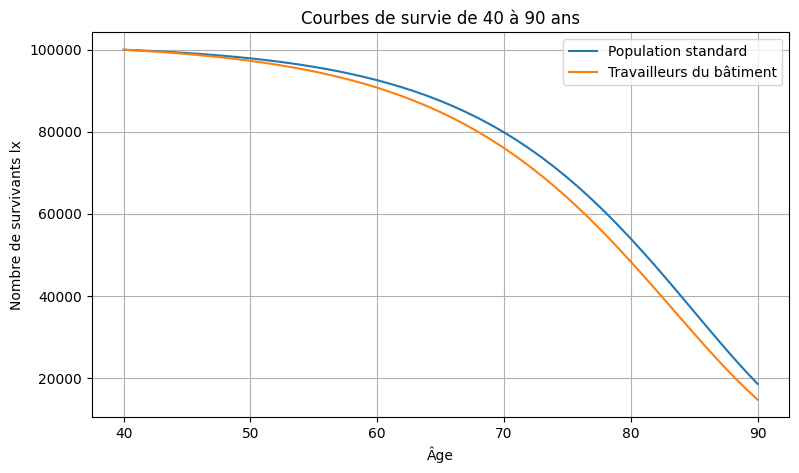

In [ ]:
# ------------------------------------------------------------
# 6. Tracé des courbes de survie lx
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))
plt.plot(table_standard["age"], table_standard["lx"], label="Population standard")
plt.plot(table_btp["age"], table_btp["lx"], label="Travailleurs du bâtiment")

plt.xlabel("Âge")
plt.ylabel("Nombre de survivants lx")
plt.title("Courbes de survie de 40 à 90 ans")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ------------------------------------------------------------
# 7. Optionnel : export des tables vers Excel / CSV
# ------------------------------------------------------------
table_standard.to_csv("mortality_table_standard.csv", index=False)
table_btp.to_csv("mortality_table_construction_workers.csv", index=False)

df_input.to_csv("input_mortality_points.csv", index=False)
fit_standard["table"].to_csv("gompertz_fit_standard.csv", index=False)
fit_btp["table"].to_csv("gompertz_fit_construction_workers.csv", index=False)

print("\nFichiers exportés avec succès.")


Fichiers exportés avec succès.


=== DONNÉES D’ENTRÉE PARTIE 4 (Contrat B) ===
25p40 (travailleurs du bâtiment) = 0.847602
25q40 (travailleurs du bâtiment) = 0.152398
a_65^(25)                        = 12.219263
ä_40:25                          = 18.110644
APV_B (prime unique nette)       = 27,932.54
GSP_B (prime unique brute)       = 31,284.44
P_net                            = 1,542.33
P_gross                          = 1,727.41
Chargement annuel                = 185.08

=== TESTS DE COHÉRENCE ===
R(25) issu de la récurrence                 = 61,096.32
5000 * v^25 * 25p40 * a65^(25)              = 27,932.54
5000 * a65^(25)                             = 61,096.32


<>:84: SyntaxWarning: invalid escape sequence '\o'
<>:84: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_300/1570582997.py:84: SyntaxWarning: invalid escape sequence '\o'
  ä_{x:\overline{n}|} = sum_{k=0}^{n-1} v^k * {}_k p_x


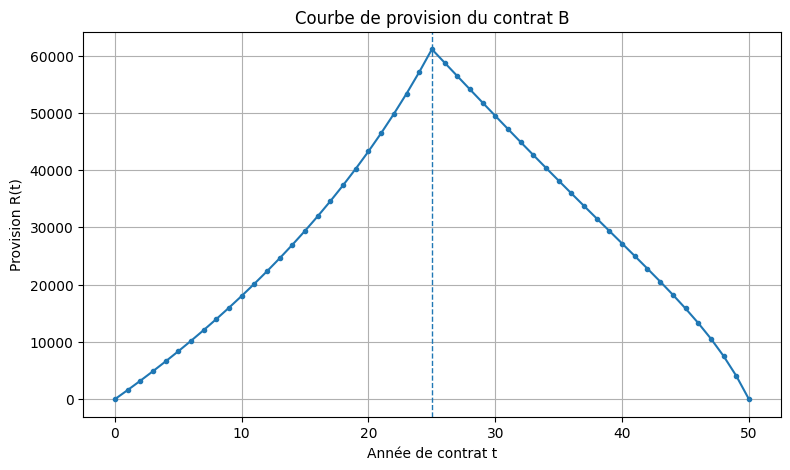


=== SYNTHÈSE DE RENTABILITÉ ===
Profit total non actualisé      = 23,085.01
Profit total actualisé (4%)     = 9,349.44


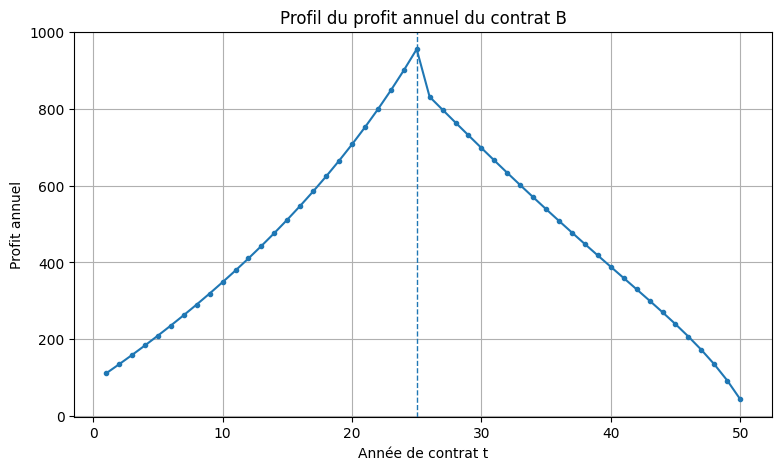


Fichiers exportés :
- reserve_schedule_contract_B.csv
- profit_schedule_contract_B.csv


In [ ]:

# PARTIE 4 - PROVISIONNEMENT ET ANALYSE DE RENTABILITÉ (CONTRAT B)
# Rente viagère différée pour un travailleur du bâtiment âgé de 40 ans


# 0. DONNÉES D'ENTRÉE
# Hypothèses techniques du projet
r_tech = 0.025           # taux technique utilisé pour la tarification / le provisionnement
i_asset = 0.04           # rendement des actifs utilisé pour l’analyse de rentabilité
v = 1 / (1 + r_tech)

benefit_annuity = 5000   # montant annuel de la rente
expense_per_year = 100   # frais annuels de gestion si l’assuré est vivant
loading_rate = 0.12      # chargement appliqué à la VAP
age_start = 40
age_retirement = 65
age_end = 90

deferral_years = age_retirement - age_start   # 25 ans
annuity_years = age_end - age_retirement      # 25 ans
horizon = age_end - age_start                 # 50 ans

# 1. Reconstruction table mortalité

# Paramètres de Gompertz estimés précédemment pour les travailleurs du bâtiment
B_cw = 4.3008e-05
c_cw = 1.09706

ages_full = np.arange(age_start, age_end + 1)
qx_cw = np.clip(B_cw * (c_cw ** ages_full), 0, 1)
px_cw = 1 - qx_cw

lx_cw = np.zeros(len(ages_full))
dx_cw = np.zeros(len(ages_full))
lx_cw[0] = 100000

for i in range(len(ages_full) - 1):
    dx_cw[i] = lx_cw[i] * qx_cw[i]
    lx_cw[i + 1] = lx_cw[i] - dx_cw[i]

dx_cw[-1] = lx_cw[-1] * qx_cw[-1]

table_btp = pd.DataFrame({
    "age": ages_full,
    "qx": qx_cw,
    "px": px_cw,
    "lx": lx_cw,
    "dx": dx_cw
})


# 2. Fonctions auxilières

def get_lx(table, age):
    """Renvoie l_x à partir de la table de mortalité."""
    return float(table.loc[table["age"] == age, "lx"].iloc[0])

def get_px(table, age):
    """Renvoie p_x à partir de la table de mortalité."""
    return float(table.loc[table["age"] == age, "px"].iloc[0])

def npx(table, x, n):
    """
    Probabilité de survie {}_n p_x = l_{x+n} / l_x.
    Exemple : npx(table_btp, 40, 25) = probabilité de survivre de 40 à 65 ans.
    """
    lx = get_lx(table, x)
    lx_n = get_lx(table, x + n)
    return lx_n / lx

def annuity_immediate(table, x, n, rate):
    """
    Facteur de rente immédiate à l’âge x pour au plus n paiements :
        a_x^{(n)} = sum_{k=1}^n v^k * {}_k p_x
    """
    v_local = 1 / (1 + rate)
    value = 0.0
    for k in range(1, n + 1):
        value += (v_local ** k) * npx(table, x, k)
    return value

def annuity_due_temp(table, x, n, rate):
    """
    Facteur de rente temporaire à échoir :
        ä_{x:\overline{n}|} = sum_{k=0}^{n-1} v^k * {}_k p_x
    """
    v_local = 1 / (1 + rate)
    value = 0.0
    for k in range(0, n):
        value += (v_local ** k) * npx(table, x, k)
    return value


# 3. Recalcul primes contrat B

# Quantités nécessaires pour la Partie 3 / Partie 4
p25_40 = npx(table_btp, 40, 25)
q25_40 = 1 - p25_40
a65_25 = annuity_immediate(table_btp, 65, 25, r_tech)
adue_40_25 = annuity_due_temp(table_btp, 40, 25, r_tech)

# Prime unique nette du contrat B
APV_B = benefit_annuity * (v ** 25) * p25_40 * a65_25

# Prime unique brute
GSP_B = (1 + loading_rate) * APV_B

# Prime annuelle nette pendant le différé
P_net = APV_B / adue_40_25

# Prime annuelle brute pendant le différé
P_gross = GSP_B / adue_40_25

# Chargement annuel perçu pendant le différé
# Comme la prime brute = prime nette + chargement, on a :
annual_loading = P_gross - P_net

print("=== DONNÉES D’ENTRÉE PARTIE 4 (Contrat B) ===")
print(f"25p40 (travailleurs du bâtiment) = {p25_40:.6f}")
print(f"25q40 (travailleurs du bâtiment) = {q25_40:.6f}")
print(f"a_65^(25)                        = {a65_25:.6f}")
print(f"ä_40:25                          = {adue_40_25:.6f}")
print(f"APV_B (prime unique nette)       = {APV_B:,.2f}")
print(f"GSP_B (prime unique brute)       = {GSP_B:,.2f}")
print(f"P_net                            = {P_net:,.2f}")
print(f"P_gross                          = {P_gross:,.2f}")
print(f"Chargement annuel                = {annual_loading:,.2f}")


# 4. Trajectoire de provision


reserve_rows = []
R = np.zeros(horizon + 1)   # R[0], ..., R[50]
R[0] = 0.0

for t in range(1, horizon + 1):
    age_t_minus_1 = age_start + t - 1
    p_survive_one_year = get_px(table_btp, age_t_minus_1)

    if t <= deferral_years:
        premium_received = P_net
        expected_claim = 0.0

        R[t] = ((R[t - 1] + premium_received) * (1 + r_tech)) / p_survive_one_year

    else:
        premium_received = 0.0
        expected_claim = benefit_annuity * p_survive_one_year

        R[t] = (R[t - 1] * (1 + r_tech) - expected_claim) / p_survive_one_year

    reserve_rows.append({
        "t": t,
        "age_start_year": age_t_minus_1,
        "R_t_minus_1": R[t - 1],
        "premium_received": premium_received,
        "p_x": p_survive_one_year,
        "expected_claim": expected_claim,
        "R_t": R[t]
    })

reserve_df = pd.DataFrame(reserve_rows)

# Forcer la dernière provision à zéro si l’on veut une cohérence exacte de présentation
# avec le point terminal du projet. On conserve ici les deux valeurs :
R50_raw = R[50]
reserve_df.loc[reserve_df["t"] == 50, "R_t_raw"] = R50_raw


# 5. Test de cohérence à t = 25


R25 = R[25]
check_project_formula = benefit_annuity * (v ** 25) * p25_40 * a65_25
check_retirement_value = benefit_annuity * a65_25

print("\n=== TESTS DE COHÉRENCE ===")
print(f"R(25) issu de la récurrence                 = {R25:,.2f}")
print(f"5000 * v^25 * 25p40 * a65^(25)              = {check_project_formula:,.2f}")
print(f"5000 * a65^(25)                             = {check_retirement_value:,.2f}")


# 6. TRACÉ DE LA COURBE DE PROVISION

plt.figure(figsize=(9, 5))
plt.plot(np.arange(0, horizon + 1), R, marker="o", markersize=3)
plt.axvline(deferral_years, linestyle="--", linewidth=1)
plt.xlabel("Année de contrat t")
plt.ylabel("Provision R(t)")
plt.title("Courbe de provision du contrat B")
plt.grid(True)
plt.show()


# 7. Décomposition du profit annuel

# Profit = marge financière + gain/perte de mortalité + reprise de chargement

profit_rows = []

for t in range(1, horizon + 1):
    age_t_minus_1 = age_start + t - 1

    # Probabilité de survie entre 40 ans et le début de l’année t
    prob_alive_start_year = npx(table_btp, 40, t - 1)

    if t <= deferral_years:
        financial_margin = (i_asset - r_tech) * (R[t - 1] + P_gross)
        loading_release = annual_loading * prob_alive_start_year - expense_per_year * prob_alive_start_year
        premium_for_info = P_gross
    else:
        financial_margin = (i_asset - r_tech) * R[t - 1]
        loading_release = -expense_per_year * prob_alive_start_year
        premium_for_info = 0.0

    mortality_gain = 0.0

    annual_profit = financial_margin + mortality_gain + loading_release

    # Actualisation du profit annuel au taux de rendement des actifs (4%)
    # pour obtenir sa contribution à la VAN
    discounted_profit = annual_profit / ((1 + i_asset) ** t)

    profit_rows.append({
        "t": t,
        "age_start_year": age_t_minus_1,
        "prob_alive_start_year": prob_alive_start_year,
        "reserve_start": R[t - 1],
        "premium_info": premium_for_info,
        "financial_margin": financial_margin,
        "mortality_gain": mortality_gain,
        "loading_release": loading_release,
        "annual_profit": annual_profit,
        "discounted_profit_4pct": discounted_profit
    })

profit_df = pd.DataFrame(profit_rows)

# 8. Synthèse rentabilité

total_profit_undiscounted = profit_df["annual_profit"].sum()
total_profit_discounted_4pct = profit_df["discounted_profit_4pct"].sum()

print("\n=== SYNTHÈSE DE RENTABILITÉ ===")
print(f"Profit total non actualisé      = {total_profit_undiscounted:,.2f}")
print(f"Profit total actualisé (4%)     = {total_profit_discounted_4pct:,.2f}")

# 9. TRACÉ DU PROFIL DE PROFIT ANNUEL

plt.figure(figsize=(9, 5))
plt.plot(profit_df["t"], profit_df["annual_profit"], marker="o", markersize=3)
plt.axvline(deferral_years, linestyle="--", linewidth=1)
plt.xlabel("Année de contrat t")
plt.ylabel("Profit annuel")
plt.title("Profil du profit annuel du contrat B")
plt.grid(True)
plt.show()


# 10. Export tables pour export

reserve_df.to_csv("reserve_schedule_contract_B.csv", index=False)
profit_df.to_csv("profit_schedule_contract_B.csv", index=False)

print("\nFichiers exportés :")
print("- reserve_schedule_contract_B.csv")
print("- profit_schedule_contract_B.csv")

